# IT5006 - Candidate Problem 1
## Delivery Lead Time Prediction

**Contributor:** Chai Winnie
**Extends:** `IT5006-Olist_Getting_Started.ipynb` (continues from the consolidated dataset built in that notebook's Section 3)

This notebook explores whether delivery lead time can be predicted before an order is delivered,
framed as both a regression on the purchase-to-delivery duration and a classification of on-time
versus late status against Olist's estimated delivery date. It walks through each candidate
predictor tested during EDA (distance, purchase timing, payment method, order complexity, order
weight) and closes with how the target itself should be defined for Phase 2.


---

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


pandas: 3.0.5
numpy: 2.4.6


In [2]:
# === DATA PATH CONFIGURATION ===
# Option 1: Google Colab with Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = "/content/drive/MyDrive/2026_work/IS5126/Olist"

# Option 2: cloned GitHub repo (recommended if running fresh in Colab)
# !git clone https://github.com/YuanJiayi/IT5006_Grp_6.git
# DATA_DIR = "IT5006_Grp_6/data"

# Option 3: local path
DATA_DIR = "../data"  # adjust as needed (relative to milestone1_notebooks/)

if os.path.exists(DATA_DIR):
    print(f"Data directory found: {DATA_DIR}")
else:
    print(f"Data directory not found: {DATA_DIR}")
    print("Please update DATA_DIR to point to your Olist data folder")


Data directory found: ../data


In [3]:
def load_candidate1_data(data_dir):
    """Load the tables this notebook needs. Approval/carrier timestamps and payment
    type live in the raw tables, not the consolidated file, so both are loaded."""

    tables = {
        'consolidated': 'smartcommerce_consolidated.csv',
        'orders': 'olist_orders_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
    }
    date_cols = {
        'consolidated': ['order_purchase_timestamp', 'order_delivered_customer_date',
                          'order_estimated_delivery_date'],
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date'],
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows x {data[name].shape[1]} cols")

    return data

olist = load_candidate1_data(DATA_DIR)


Loaded consolidated: 112,650 rows x 25 cols


Loaded orders: 99,441 rows x 8 cols


Loaded customers: 99,441 rows x 5 cols


Loaded sellers: 3,095 rows x 4 cols


Loaded geolocation: 1,000,163 rows x 5 cols


Loaded reviews: 99,224 rows x 7 cols


Loaded payments: 103,886 rows x 5 cols


In [4]:
line_items = olist['consolidated']
eligible = line_items.loc[
    line_items['order_status'].eq('delivered')
    & line_items['order_delivered_customer_date'].notna()
    & line_items['order_estimated_delivery_date'].notna()
].copy()
orders = eligible.drop_duplicates('order_id').copy()
orders['is_late'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']
print(f"Eligible delivered orders: {len(orders):,}")


Eligible delivered orders: 96,470


---

## 1. Delivery time and late-rate by customer-seller distance

In [5]:
def haversine_km(lat1, lng1, lat2, lng2):
    radius = 6371.0
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    inner = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(inner))

centroids = olist['geolocation'].groupby('geolocation_zip_code_prefix', as_index=False).agg(
    lat=('geolocation_lat', 'mean'), lng=('geolocation_lng', 'mean')
)
customers = olist['customers'][['customer_id', 'customer_zip_code_prefix']]
sellers = olist['sellers'][['seller_id', 'seller_zip_code_prefix']]

dist = orders[['order_id', 'customer_id', 'seller_id', 'delivery_days', 'is_late']].merge(
    customers, on='customer_id', how='left'
).merge(sellers, on='seller_id', how='left')
dist = dist.merge(
    centroids.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
                               'lat': 'cust_lat', 'lng': 'cust_lng'}),
    on='customer_zip_code_prefix', how='left',
).merge(
    centroids.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
                               'lat': 'sell_lat', 'lng': 'sell_lng'}),
    on='seller_zip_code_prefix', how='left',
)
dist['distance_km'] = haversine_km(dist['cust_lat'], dist['cust_lng'], dist['sell_lat'], dist['sell_lng'])
dist = dist.dropna(subset=['distance_km'])
dist['distance_bucket'] = pd.qcut(dist['distance_km'], 6, duplicates='drop')

distance_buckets = dist.groupby('distance_bucket', observed=True).agg(
    mean_delivery_days=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean'),
    orders=('order_id', 'size'),
).reset_index()
distance_buckets['late_rate'] *= 100
distance_buckets['distance_label'] = distance_buckets['distance_bucket'].apply(
    lambda interval: f"{max(interval.left, 0):,.0f}-{interval.right:,.0f}"
)
distance_buckets[['distance_label', 'mean_delivery_days', 'late_rate', 'orders']]


,distance_label,mean_delivery_days,late_rate,orders
0,0-85,5.92,6.30,15999
1,85-305,9.29,6.51,15999
2,305-434,11.91,7.71,15998
3,434-627,12.59,7.93,15999
4,627-964,14.27,8.54,15998
5,"964-8,678",18.53,11.62,15999


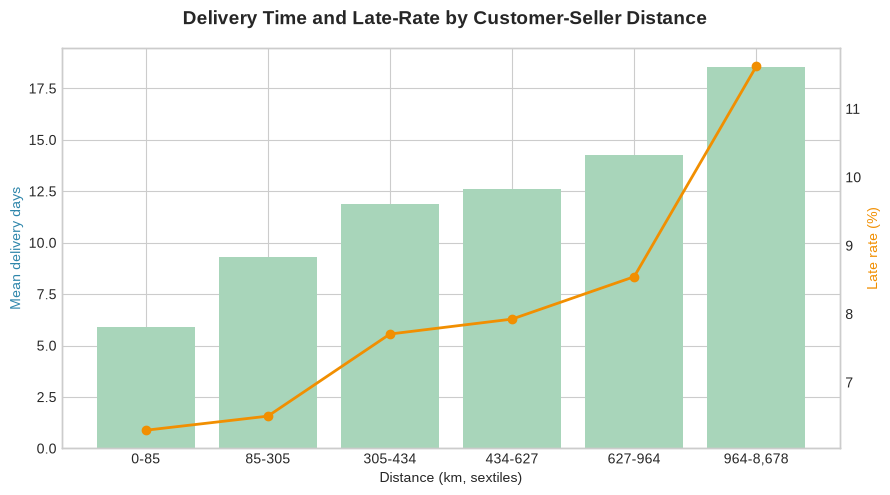

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(9, 5))
fig.suptitle('Delivery Time and Late-Rate by Customer-Seller Distance', fontsize=14, fontweight='bold')

ax1.bar(distance_buckets['distance_label'], distance_buckets['mean_delivery_days'], color='#A8D5BA')
ax1.set_xlabel('Distance (km, sextiles)')
ax1.set_ylabel('Mean delivery days', color='#2E86AB')

ax2 = ax1.twinx()
ax2.plot(distance_buckets['distance_label'], distance_buckets['late_rate'], color='#F18F01', linewidth=2, marker='o')
ax2.set_ylabel('Late rate (%)', color='#F18F01')
ax2.grid(False)

plt.tight_layout()
plt.show()


**Finding:** Mean delivery time more than triples across distance sextiles, from 5.9 days for the
closest sixth of orders to 18.5 days for the farthest, while the late-delivery rate rises far more
gently (6.3% to 11.6%). This divergence suggests Olist's own estimated delivery date already
partly adjusts for distance, making distance a stronger predictor for the regression target than
for the classification target.


---

## 2. Purchase timing: day-of-week x hour heatmap

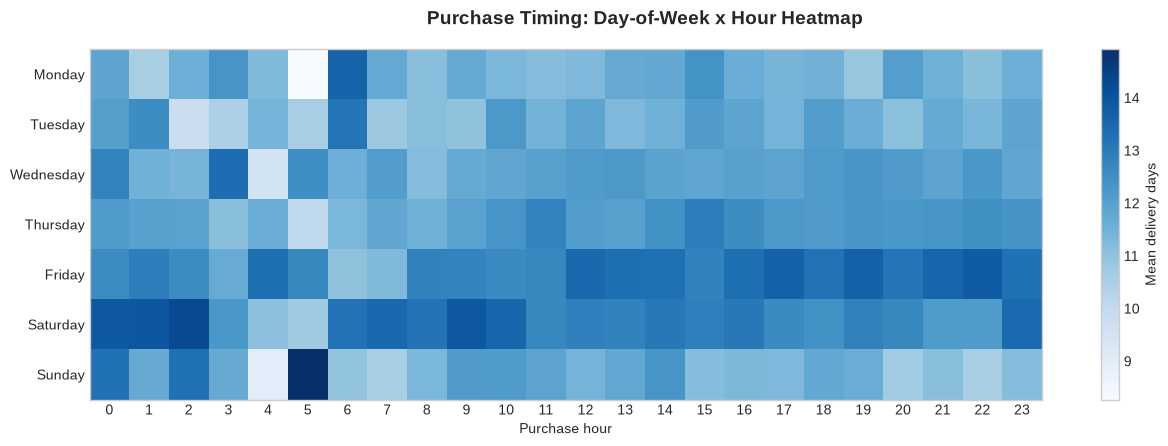

In [7]:
heatmap_data = orders.assign(purchase_hour=orders['order_purchase_timestamp'].dt.hour).groupby(
    ['day_of_week', 'purchase_hour'], as_index=False
).agg(mean_delivery_days=('delivery_days', 'mean'), orders=('order_id', 'size'))

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = heatmap_data.pivot(index='day_of_week', columns='purchase_hour', values='mean_delivery_days').reindex(DAY_ORDER)

fig, ax = plt.subplots(figsize=(13, 4.5))
fig.suptitle('Purchase Timing: Day-of-Week x Hour Heatmap', fontsize=14, fontweight='bold')
im = ax.imshow(pivot.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Purchase hour')
ax.grid(False)
fig.colorbar(im, ax=ax, label='Mean delivery days')
plt.tight_layout()
plt.show()


**Finding:** Purchase day and hour are observed at order placement and therefore carry no
lookahead risk as model inputs. Mean delivery time is not uniformly distributed across the
purchase window, supporting purchase timing as a viable, zero-cost predictor for the lead-time
model.


---

## 3. Mean delivery time by day of week purchased

In [8]:
weekday_summary = orders.groupby('day_of_week', as_index=False).agg(
    mean_delivery_days=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean'),
    orders=('order_id', 'size'),
).set_index('day_of_week').reindex(DAY_ORDER).reset_index()
weekday_summary['late_rate'] *= 100
weekday_summary


,day_of_week,mean_delivery_days,late_rate,orders
0,Monday,11.53,9.05,15701
1,Tuesday,11.61,8.49,15502
2,Wednesday,11.98,7.80,15074
3,Thursday,12.28,7.57,14322
4,Friday,13.12,8.45,13684
5,Saturday,12.89,7.60,10555
6,Sunday,11.47,7.49,11632


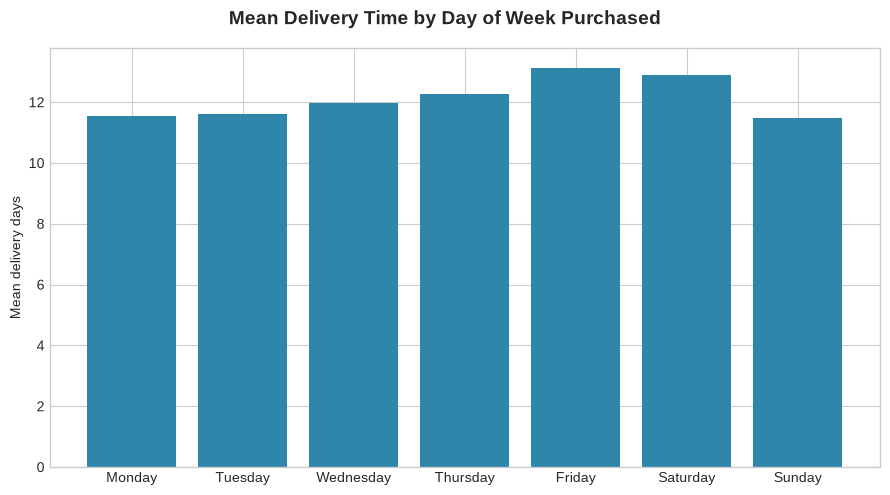

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Mean Delivery Time by Day of Week Purchased', fontsize=14, fontweight='bold')
ax.bar(weekday_summary['day_of_week'], weekday_summary['mean_delivery_days'], color='#2E86AB')
ax.set_ylabel('Mean delivery days')
plt.tight_layout()
plt.show()


**Finding:** Mean delivery time varies by purchase day, ranging from 11.47 days for Sunday
purchases to 13.12 days for Friday purchases, a difference of approximately 14%. This indicates
purchase day of week carries predictive signal independent of distance or payment method.


---

## 4. Which stage slows down for weekend purchases?

In [10]:
stages = olist['orders'].dropna(subset=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
]).copy()
stages['processing_time'] = (stages['order_approved_at'] - stages['order_purchase_timestamp']).dt.total_seconds() / 86400
stages['handling_time'] = (stages['order_delivered_carrier_date'] - stages['order_approved_at']).dt.total_seconds() / 86400
stages['shipping_time'] = (stages['order_delivered_customer_date'] - stages['order_delivered_carrier_date']).dt.total_seconds() / 86400
STAGE_COLS = ['processing_time', 'handling_time', 'shipping_time']
stage_clean = stages.loc[(stages[STAGE_COLS] >= 0).all(axis=1)].copy()
stage_clean['day_of_week'] = stage_clean['order_purchase_timestamp'].dt.day_name()

stage_dow = stage_clean.groupby('day_of_week')[STAGE_COLS].mean().reindex(DAY_ORDER)
stage_dow


,processing_time,handling_time,shipping_time
day_of_week,,,
Monday,0.36,2.38,9.31
Tuesday,0.34,2.53,9.28
Wednesday,0.34,2.68,9.51
Thursday,0.35,3.04,9.40
Friday,0.51,3.71,9.38
Saturday,0.56,3.33,9.53
Sunday,0.41,2.45,9.16


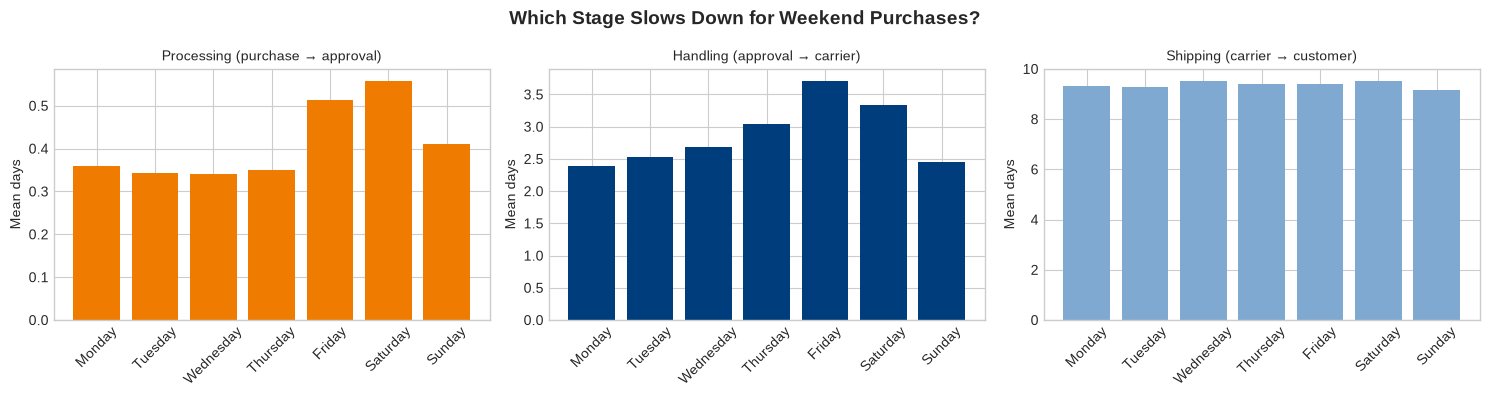

In [11]:
STAGE_LABELS = {'processing_time': 'Processing (purchase \u2192 approval)',
                'handling_time': 'Handling (approval \u2192 carrier)',
                'shipping_time': 'Shipping (carrier \u2192 customer)'}
STAGE_COLORS = {'processing_time': '#EF7C00', 'handling_time': '#003D7C', 'shipping_time': '#7FA9D0'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Which Stage Slows Down for Weekend Purchases?', fontsize=14, fontweight='bold')
for ax, stage_key in zip(axes, STAGE_COLS):
    ax.bar(stage_dow.index, stage_dow[stage_key], color=STAGE_COLORS[stage_key])
    ax.set_title(STAGE_LABELS[stage_key], fontsize=10)
    ax.set_ylabel('Mean days')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Finding:** Decomposing total lead time into its three stages localises the day-of-week effect
to the order-handling stage (approval to carrier pickup); the shipping stage stays approximately
constant regardless of purchase day. The day-of-week effect originates in Olist's internal
order-handling process rather than in carrier transit, a distinction relevant to feature
attribution.


---

## 5. Delivery time by payment method

In [12]:
primary_payments = olist['payments'].loc[
    olist['payments']['payment_sequential'].eq(1), ['order_id', 'payment_type']
]
pay_orders = orders.merge(primary_payments, on='order_id', how='inner')
payment_cuts = pay_orders.groupby('payment_type', as_index=False).agg(
    mean_delivery_days=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean'),
    orders=('order_id', 'size'),
)
payment_cuts = payment_cuts.loc[payment_cuts['orders'] >= 50].sort_values('orders', ascending=False)
payment_cuts['late_rate'] *= 100
payment_order = payment_cuts['payment_type'].tolist()
payment_cuts


,payment_type,mean_delivery_days,late_rate,orders
1,credit_card,11.88,7.94,74268
0,boleto,13.04,8.88,19190
3,voucher,12.02,6.94,1498
2,debit_card,10.21,8.01,1435


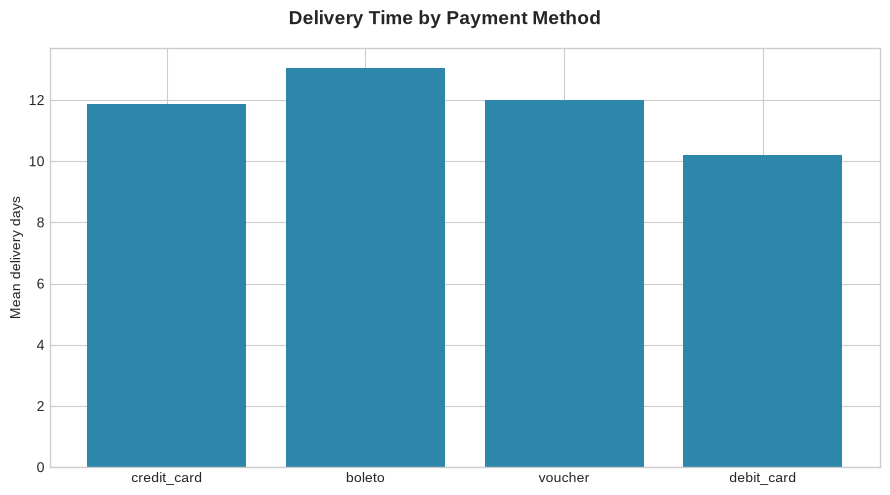

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Delivery Time by Payment Method', fontsize=14, fontweight='bold')
ax.bar(payment_cuts['payment_type'], payment_cuts['mean_delivery_days'], color='#2E86AB')
ax.set_ylabel('Mean delivery days')
plt.tight_layout()
plt.show()


**Finding:** Mean delivery time differs by payment method: Boleto orders average 13.04 days
versus 11.88 for credit card. This is consistent with Boleto's manual bank-confirmation
requirement, which delays order approval prior to fulfilment.


---

## 6. Lead-time breakdown by payment method

In [14]:
stage_pay = stage_clean.merge(primary_payments, on='order_id', how='inner')
stage_pay_summary = stage_pay.groupby('payment_type')[STAGE_COLS].mean().reindex(payment_order)
stage_pay_summary


,processing_time,handling_time,shipping_time
payment_type,,,
credit_card,0.16,2.86,9.38
boleto,1.34,2.82,9.40
voucher,0.38,2.79,9.37
debit_card,0.28,2.75,7.71


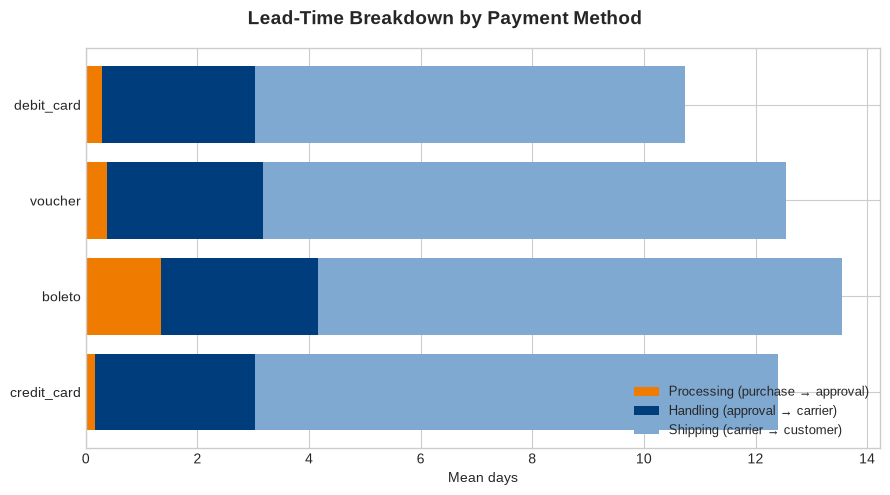

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Lead-Time Breakdown by Payment Method', fontsize=14, fontweight='bold')
left = pd.Series(0, index=stage_pay_summary.index, dtype=float)
for stage_key in STAGE_COLS:
    ax.barh(stage_pay_summary.index, stage_pay_summary[stage_key], left=left,
            color=STAGE_COLORS[stage_key], label=STAGE_LABELS[stage_key])
    left += stage_pay_summary[stage_key]
ax.set_xlabel('Mean days')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


**Finding:** The same stage decomposition, grouped by payment method, confirms that Boleto's
additional lead time is concentrated in the processing stage (purchase to approval), consistent
with the manual confirmation requirement, rather than being distributed across handling or
shipping.


---

## 7. Delivery time by order complexity

In [16]:
item_counts = line_items.groupby('order_id').size().rename('item_count')
seller_counts = line_items.groupby('order_id')['seller_id'].nunique().rename('seller_count')
complexity = orders[['order_id', 'delivery_days']].merge(item_counts, on='order_id').merge(seller_counts, on='order_id')

groups = {
    'Single item': complexity['item_count'].eq(1),
    'Multiple items': complexity['item_count'].gt(1),
    'Single seller': complexity['item_count'].gt(1) & complexity['seller_count'].eq(1),
    'Multiple sellers': complexity['item_count'].gt(1) & complexity['seller_count'].gt(1),
}
complexity_delivery = pd.DataFrame([
    {'group': label, 'mean_delivery_days': complexity.loc[mask, 'delivery_days'].mean(), 'orders': int(mask.sum())}
    for label, mask in groups.items()
])
complexity_delivery


,group,mean_delivery_days,orders
0,Single item,12.17,86835
1,Multiple items,11.36,9635
2,Single seller,11.78,8360
3,Multiple sellers,8.66,1275


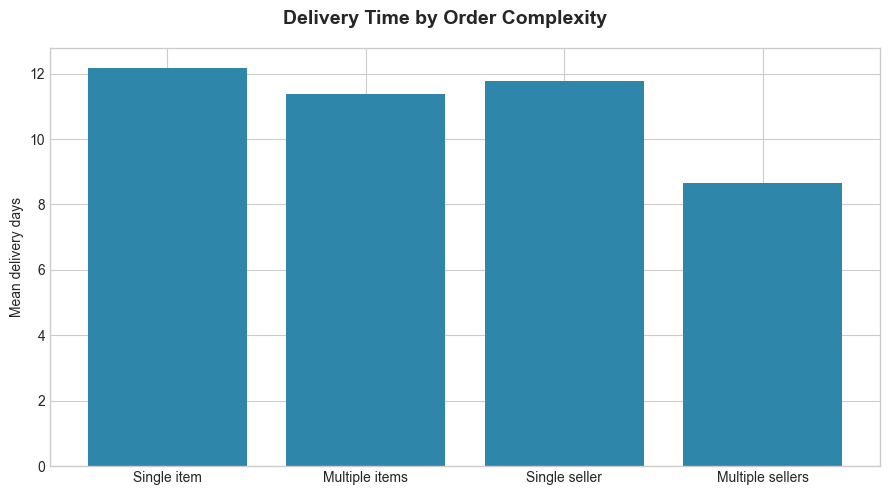

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Delivery Time by Order Complexity', fontsize=14, fontweight='bold')
ax.bar(complexity_delivery['group'], complexity_delivery['mean_delivery_days'], color='#2E86AB')
ax.set_ylabel('Mean delivery days')
plt.tight_layout()
plt.show()


**Finding:** Order complexity shows a counter-intuitive relationship with delivery time:
among multi-item orders, multi-seller orders arrive faster on average than single-seller orders
(8.66 vs. 11.78 days),
and multi-item orders arrive modestly faster than single-item orders (11.36 vs. 12.17 days). The
multi-seller group is comparatively small (n = 1,275), so this estimate should be treated with
some caution pending further investigation of the underlying mechanism.


---

## 8. Delivery time by order weight

In [18]:
order_weight = line_items.groupby('order_id', as_index=False)['product_weight_g'].sum()
weight_orders = orders[['order_id', 'delivery_days', 'is_late']].merge(order_weight, on='order_id', how='left').dropna()
weight_orders = weight_orders.loc[weight_orders['product_weight_g'] > 0].copy()
weight_orders['weight_bucket'] = pd.qcut(weight_orders['product_weight_g'], 6, duplicates='drop')

weight_buckets = weight_orders.groupby('weight_bucket', observed=True).agg(
    mean_delivery_days=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean'),
    orders=('order_id', 'size'),
).reset_index()
weight_buckets['late_rate'] *= 100
weight_buckets['weight_label'] = weight_buckets['weight_bucket'].apply(
    lambda interval: f"{max(interval.left, 0):,.0f}-{interval.right:,.0f}"
)
weight_buckets[['weight_label', 'mean_delivery_days', 'late_rate', 'orders']]


,weight_label,mean_delivery_days,late_rate,orders
0,2-215,11.30,7.51,16078
1,215-400,11.63,8.26,17176
2,400-750,11.78,7.65,15522
3,"750-1,452",11.97,7.81,15523
4,"1,452-3,600",12.51,8.50,16181
5,"3,600-184,400",13.40,8.93,15968


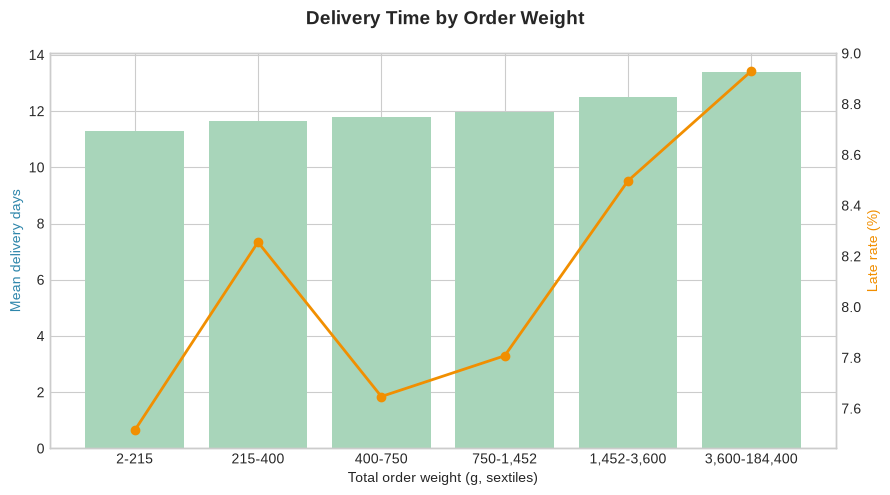

In [19]:
fig, ax1 = plt.subplots(figsize=(9, 5))
fig.suptitle('Delivery Time by Order Weight', fontsize=14, fontweight='bold')
ax1.bar(weight_buckets['weight_label'], weight_buckets['mean_delivery_days'], color='#A8D5BA')
ax1.set_xlabel('Total order weight (g, sextiles)')
ax1.set_ylabel('Mean delivery days', color='#2E86AB')

ax2 = ax1.twinx()
ax2.plot(weight_buckets['weight_label'], weight_buckets['late_rate'], color='#F18F01', linewidth=2, marker='o')
ax2.set_ylabel('Late rate (%)', color='#F18F01')
ax2.grid(False)

plt.tight_layout()
plt.show()


**Finding:** Total order weight shows only a weak association with delivery time and late-rate
relative to distance; both series are comparatively flat across weight sextiles. On its own,
weight is a weaker candidate predictor for the lead-time model than distance, purchase timing, or
payment method.


---

### What this notebook found

Distance, purchase timing and payment method each show a clear, pre-delivery relationship with
lead time, while order weight is only weakly related and order complexity runs counter to
intuition (multi-seller orders arrive faster, not slower). Every feature tested is observable at
the moment the order is placed, so the lead-time target carries no leakage risk from its
strongest predictors. The remaining open question is how to define the on-time/late label itself:
Olist's own estimated delivery date is not fixed, it widens with a lag after demand spikes
(see `operational_capacity.ipynb`), so Phase 2 will need to choose between classifying against
Olist's own shifting estimate or a fixed lead-time threshold defined independently of it.
